In [4]:
library(data.table)
library(GenomicRanges)
library(ggplot2)
options(warn = -1)

[1] 0.9208881

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.7500  0.9084  0.9250  0.9193  0.9400  1.0000       2 

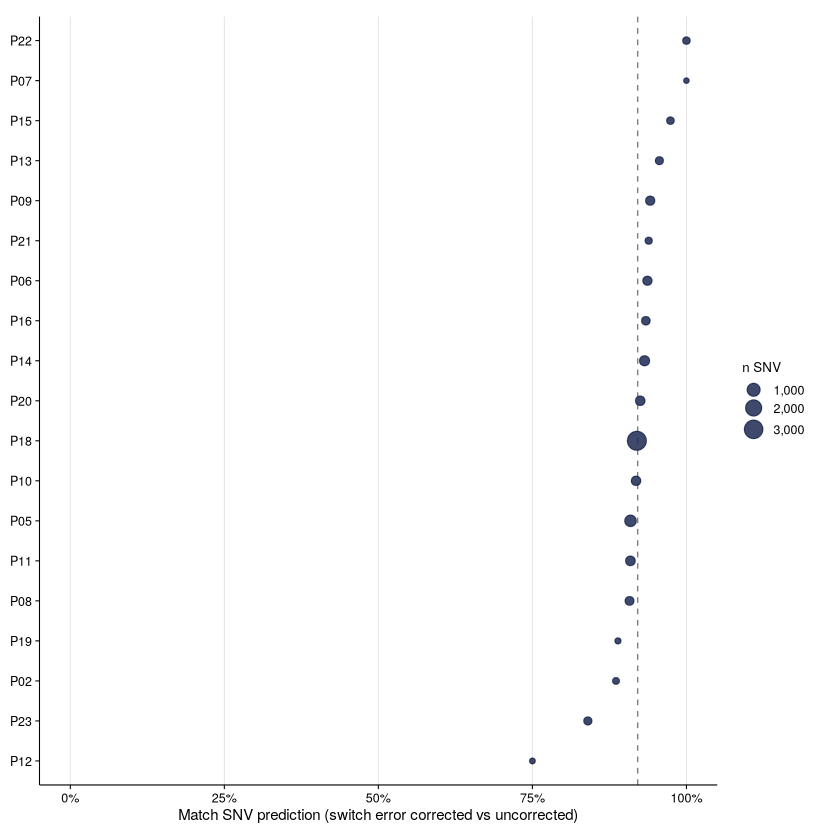

In [22]:
info_ma <- read.table("/srv/home/mlef0011/Phasomix/output/local_ancestry/prediction/high_coverage/IS_corrected/input_path_F1_like_mono_x_admixed_gnomix_PCAWG_POP_no_AMR.tsv", header = TRUE, sep = "\t")

samples <- info_ma$sample
samples <- setdiff(samples, c('0bfd1068-3fca-a95b-e050-11ac0c4860c3', '0bfd1068-3fcd-a95b-e050-11ac0c4860c3'))  # parenthese fermee

results_list <- lapply(samples, function(sample) {

  correction_path    <- paste0("/srv/home/mlef0011/Phasomix/output/quantification/", sample, "/SNV_ancestry_", sample, ".txt")
  no_correction_path <- paste0("/srv/home/mlef0011/Phasomix/output/quantification_no_correction/", sample, "/SNV_ancestry_", sample, ".txt")

  if (!file.exists(correction_path) | !file.exists(no_correction_path)) {
    return(data.frame(sample = sample, accuracy = NA, n = NA))
  }

  cn_df <- fread(info_ma$input_CNA[info_ma$sample == sample], header = TRUE, data.table = FALSE)
  iz_df <- cn_df[!is.na(cn_df$minor_cn) & !is.na(cn_df$major_cn) &
                   cn_df$major_cn != cn_df$minor_cn & cn_df$minor_cn > 0, ]
  if (nrow(iz_df) == 0) {
    return(data.frame(sample = sample, accuracy = NA, n = NA))
  }

  no_correction <- read.table(no_correction_path, header = TRUE)
  no_correction <- no_correction[, c("chr_snv", "pos_snv", "ancestry_REF", "ancestry_SNV", "haplotype_SNV")]
  colnames(no_correction)[3:5] <- paste0(colnames(no_correction)[3:5], "_no_corrected")

  correction <- read.table(correction_path, header = TRUE)
  correction <- correction[, c("chr_snv", "pos_snv", "ancestry_REF", "ancestry_SNV", "haplotype_SNV")]
  colnames(correction)[3:5] <- paste0(colnames(correction)[3:5], "_corrected")

  snv_df <- merge(no_correction, correction)
  snv_df <- snv_df[!is.na(snv_df$ancestry_SNV_corrected) & !is.na(snv_df$ancestry_SNV_no_corrected) &
                    !is.na(snv_df$ancestry_REF_corrected) & !is.na(snv_df$ancestry_REF_no_corrected), ]

  snv_df <- snv_df[snv_df$ancestry_SNV_corrected != snv_df$ancestry_REF_corrected, ]
  if (nrow(snv_df) == 0) {
    return(data.frame(sample = sample, accuracy = NA, n = NA))
  }

  gr_cn <- GRanges(
    seqnames = iz_df$chromosome,
    ranges   = IRanges(start = iz_df$start, end = iz_df$end),
    total_cn = iz_df$total_cn,
    major_cn = iz_df$major_cn,
    minor_cn = iz_df$minor_cn
  )
  gr_snv <- GRanges(
    seqnames = snv_df$chr_snv,
    ranges   = IRanges(start = snv_df$pos_snv, end = snv_df$pos_snv)
  )
  hits <- findOverlaps(gr_snv, gr_cn)
  if (length(hits) == 0) {
    return(data.frame(sample = sample, accuracy = NA, n = NA))
  }

  result <- cbind(
    snv_df[queryHits(hits), ],
    as.data.frame(mcols(gr_cn[subjectHits(hits)]))
  )

  n <- nrow(result)
  accuracy <- mean(
    result$ancestry_SNV_corrected == result$ancestry_SNV_no_corrected &
    result$ancestry_REF_corrected == result$ancestry_REF_no_corrected
  )

  data.frame(sample = sample, accuracy = accuracy, n = n)
})

results_df_snv <- do.call(rbind, results_list)
weighted_accuracy <- weighted.mean(results_df_snv$accuracy, w = results_df_snv$n, na.rm = TRUE)

weighted_accuracy
summary(results_df_snv$accuracy)

# ---- plot ----
plot_df <- results_df_snv[!is.na(results_df_snv$accuracy), ]
plot_df$patient_id <- info_ma$patient_id[match(plot_df$sample, info_ma$sample)]
plot_df$patient_id <- factor(plot_df$patient_id, levels = plot_df$patient_id[order(plot_df$accuracy)])

p1 <- ggplot(plot_df, aes(x = patient_id, y = accuracy, size = n)) +
  geom_hline(yintercept = weighted_accuracy, linetype = "dashed", color = "grey50", linewidth = 0.4) +
  geom_point(color = "#1D2951", alpha = 0.85) +
  coord_flip() +
  scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25),
                      labels = scales::percent_format(accuracy = 1)) +
  scale_size_continuous(name = "n SNV", labels = scales::comma, range = c(1.2, 5)) +
  labs(
    x = NULL,
    y = "Match SNV prediction (switch error corrected vs uncorrected)"
  ) +
  theme_minimal(base_size = 10) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_line(linewidth = 0.25, color = "grey88"),
    axis.line = element_line(color = "black", linewidth = 0.3),
    axis.ticks = element_line(color = "black", linewidth = 0.3),
    axis.text = element_text(color = "black", size = 7.5),
    axis.title = element_text(size = 9),
    legend.position = "right",
    legend.title = element_text(size = 8),
    legend.text = element_text(size = 7.5),
    legend.key.size = unit(0.35, "cm"),
    plot.margin = margin(10, 15, 10, 5)
  )

p1

ggsave("/srv/home/mlef0011/Phasomix/output/figures/snv_ancestry_concordance_IZ.png",
       p1, width = 4.5, height = 5, dpi = 600, type = "cairo")